<a href="https://colab.research.google.com/github/UNICAMP-EA979/2026s1-pi03-transforma-ointensidade-elginx/blob/main/Exerc%C3%ADcio3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Resolução do exercício 3.1
- Importar bibliotecas
- Pegar as imagens que servirão parar ser analisadas
- Código que servirá para cumprir o workflow

###Problema
Este notebook visa calcular o valor total de moedas em uma imagem, onde as moedas estão dispostas de forma separada em um fundo branco.

In [3]:
import os

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image, ImageFilter

###Passo 0
- Realiza o download de imagens a partir da sua url.

In [4]:
def download_image(url:str) -> str:
    filename = os.path.basename(url)

    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

### Passo 1
- Neste passo estou importando as imagens com as moedas, cujo valor total deverá ser calculado.
- Para isso foi feito um laço, onde será criado o url de cada imagem a partir de url_base+values[n]. Depois, ainda no laço, será feito o download da imagem a partir da url criada e, por fim, essa imagem será adicionada na lista filenames.
- Importante atentar que o formato da imagem é jpg, desta forma, os pixels já estão organizados como uma lista de 3 valores(RGB) representados em 8 bits cada.(fonte: https://en.wikipedia.org/wiki/JPEG)

In [5]:
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []

for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)

###Passo 2
- Aqui simplesmente serão plotadas as imagens selecionadas para a contagem de valores.
- Como são 3 imagens, será criada um espaço para plotagem delas.
- plt.axis('off') retira a gradação dos eixos das imagens plotadas.
- mpimg.imread() irá realizar a leitura da imagem cujo nome está guardado em 'file' e irá guardar a imagem em img.
- plt.imshow() irá plotar a imagem em questão, ajustando a posição a partir do plt.subplot().

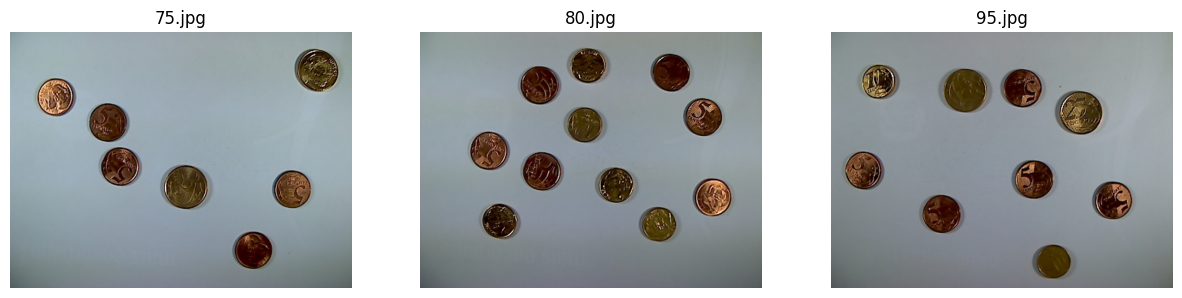

In [6]:
fig, axs = plt.subplots(1,3,figsize=(15, 6))

for i, file in enumerate(filenames):
  plt.subplot(1,3,1+i)
  plt.axis('off')
  plt.title(file)
  img = mpimg.imread(file)
  plt.imshow(img)

###Passo 3
- Neste passo será criada a função que irá fazer a segmentação e pós-processamento da imagem.
- A função cv2.thresold() irá receber uma imagem de 3 canais para gerar uma imagem em greyscale com o threshold aplicado, ou seja, gera a **imagem segmentada**. Este threshold será descoberto pelo algoritmo de Otsu, combinado com o thresh.binary. A imagem fornecida para a função será a imagem original invertida, pois queremos o fundo preto(pixel=0).(fonte: https://docs.opencv.org/4.x/d7/d1b/group__imgproc__misc.html)
- kernel_cl e kernel_op são os filtros que serão criados para processar a imagem.
- cv2.morphologyEX() irá realizar as operações morfológicas de fechamento e de abertura da imagem, realizando apenas uma iteração da operação.(fonte: https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html)
  - Fechamento: irá fechar as linhas da imagem, ou seja, realiza a conexão de objetos próximos, a definir pelo tamanho do kernel aplicado. Isso ocorre pela aplicação de dilatação da imagem seguida de erosão.
  - Abertura: irá retirar os pontinhos brancos do fundo preto. Isso ocorre pela aplicação de erosão da imagem seguida de dilatação.
  (fontes: https://homepages-inf-ed-ac-uk.translate.goog/rbf/HIPR2/dilate.htm?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc, https://homepages-inf-ed-ac-uk.translate.goog/rbf/HIPR2/erode.htm?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc)
- Por fim, serão plotadas as imagens após cada operação aplicada.

In [7]:
import cv2

def seg_and_postprocessing(img, k_cl, k_op):
    # O retorno dessa função é a imagem com threshold aplicado
    binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1] # Usa os valores da imagem negativa, pois o fundo é claro

    kernel_cl = np.ones((k_cl, k_cl), np.uint8)
    kernel_op = np.ones((k_op, k_op), np.uint8)

    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1)  # Fecha pequenos buracos no objeto e conecta componentes próximos
    open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1) # Remove pontinhos brancos no fundo preto

    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1)
    plt.imshow(binr, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(close, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(open, cmap='gray')
    plt.axis('off')
    plt.show()

    return open

###Passo 4
- Função que calcula o número de pixels da imagem que são diferentes de zero.
- A imagem que entra está com as regiões separadas e os pixels de cada região são numerados com valores diferentes.
- A iteração do laço irá calcular a soma dos valores dos pixels, porém, nessa soma ele considera cada valor de pixel como 1. Por fim, ele adiciona o valor dessa soma à lista de tamanhos de pixels.
- O retorno será a lista de tamanhos medidos a partir do número de pixels.

In [8]:
def calc_npixels_label(img, n_labels):  # img entra com o fundo 0 e as moedas são valores de 1 até n_labels
    list_npixels = []
    for v in range(n_labels-1):
        npixels = (img[img == v+1]//(v+1)).sum()  # A máscara seleciona os valores de pixels que formam as moedas. Por fim o valor é normalizado para 1 e soma-se para saber o tamanho
        list_npixels.append(npixels)  # Adiciona os valores de tamanho na lista list_npixels
    return list_npixels

###Passo 5
- Neste passo acontece de fato o processo completo.
- Inicia carregando a imagem a partir da função mpimg.imread(), forçando seus pixels a serem do tipo 'uint8'(8 bits).
- img_gray realiza a conversão da imagem de 3 bandas para o formato de escala de cinza ao aplicar a média ponderada com os pesos mais usados pelo processamento de imagens.
- seg_and_postprocessing(img_gray, 15, 31) realiza a segmentação e pós-processamento da imagem usando o kernel de fechamento com tamanho 15x15 e o kernel de abertura com tamanho 31x31. Atenção para os valores serem ímpares, pois assim é mais fácil obter um valor central.
- A função cv2.connectedComponentsWithStats(seg_img, 4) realiza a numeração das figuras contínuas a partir da conectividade de 4 direções, ou seja, considera os valores em cima, em baixo, na esquerda e na direita. Os retornos da função são o valor do número de labels, uma matriz com os valores contínuos numerados de 0(inclui o fundo) até o número total de labels, os stats(altura, largura, etc) de cada componente e os centros de cada componente.(fonte: https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html?utm_source=chatgpt.com#ga107a78bf7cd25dec05fb4dfc5c9e765f)
- Com a imagem resultante, é possível calcular o número de pixels com a função criada.
- Após isso, é feita a contagem das moedas a partir dos tamanhos aproximados que estas moedas podem possuir. Além disso, ao realizar a identificação da moeda a partir do tamanho, é incluído um texto de cor verde que rotula a moeda na imagem original das moedas.(fonte: https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html)

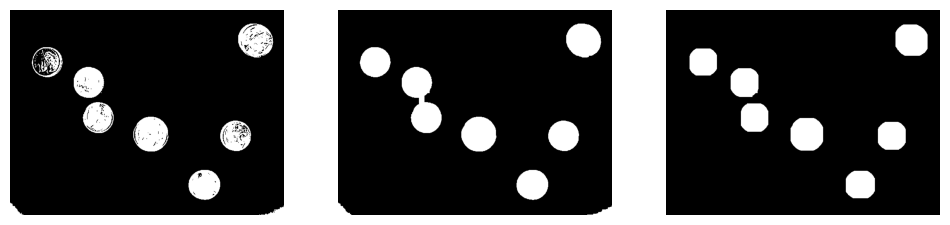

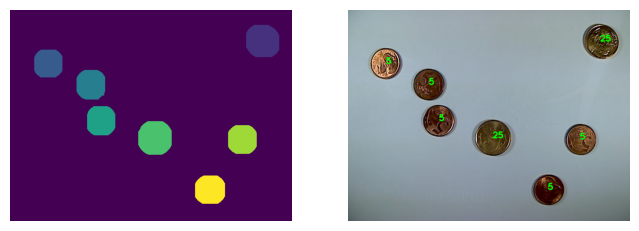

Imagem 75.jpg
Número de moedas 7
[np.int64(4805), np.int64(3638), np.int64(3867), np.int64(3786), np.int64(5016), np.int64(3767), np.int64(3861)]
Valor total: 75



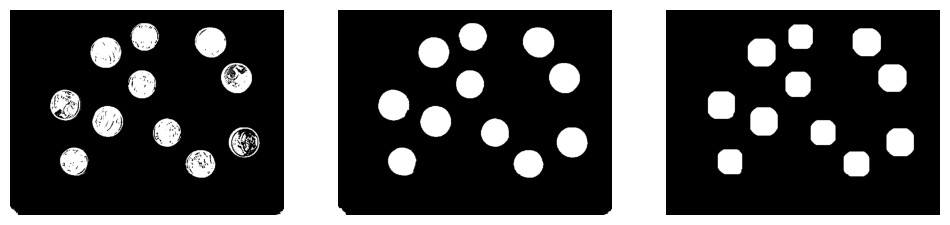

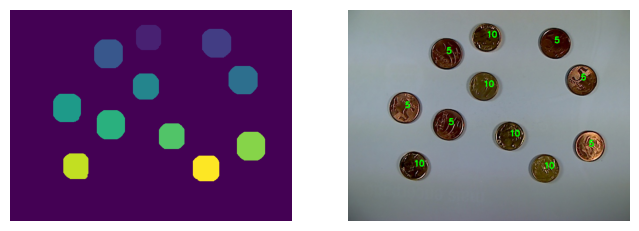

Imagem 80.jpg
Número de moedas 11
[np.int64(2978), np.int64(3793), np.int64(3775), np.int64(3736), np.int64(3132), np.int64(3678), np.int64(3778), np.int64(3064), np.int64(3728), np.int64(3049), np.int64(3183)]
Valor total: 80



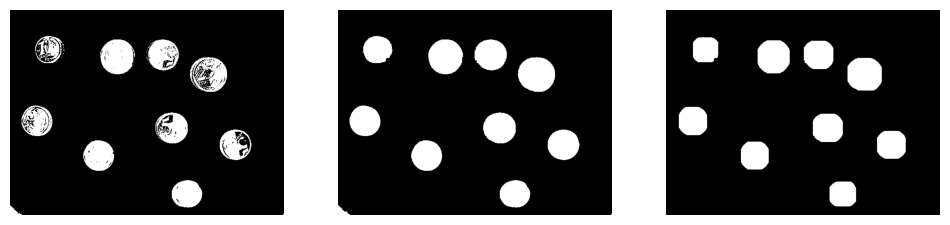

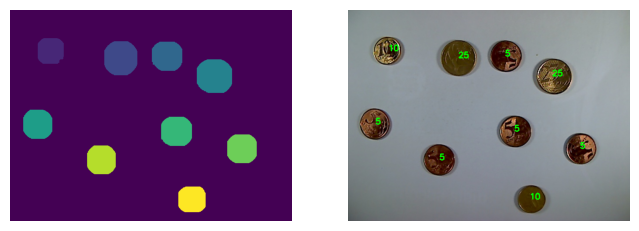

Imagem 95.jpg
Número de moedas 9
[np.int64(3114), np.int64(4997), np.int64(4017), np.int64(5335), np.int64(3845), np.int64(4113), np.int64(3897), np.int64(3766), np.int64(3285)]
Valor total: 95



In [9]:
for i, file in enumerate(filenames):
  img = mpimg.imread(file).astype('uint8')
  img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])

  seg_img = seg_and_postprocessing(img_gray, 15, 31)
  # Função abaixo retorna o número de figuras contínuas, a matriz que possui o fundo em 0 e as figuras contínuas numeradas, a matriz com os stats e os valores do centro das imagens
  # Fonte: https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html?utm_source=chatgpt.com#ga107a78bf7cd25dec05fb4dfc5c9e765f
  output = cv2.connectedComponentsWithStats(seg_img, 4)

  plt.figure(figsize=(8,4))
  plt.subplot(1,2,1)
  plt.imshow(output[1])
  plt.axis('off')

  list_npixels = calc_npixels_label(output[1], output[0])

  soma = 0
  for n, p in enumerate(list_npixels):
    x = int(output[3][n+1][0])
    y = int(output[3][n+1][1])

    if p < 3500:
      soma += 10
      cv2.putText(img, '10', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    elif p > 4600:
      soma += 25
      cv2.putText(img, '25', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    else:
      soma += 5
      cv2.putText(img, '5', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  print('Imagem', file)
  print('Número de moedas', len(list_npixels))
  print(list_npixels)
  print('Valor total:', soma)
  print()